# EEG Lab — Notebook 2/5
## Python basics and loading the EEG data

**Goals**
- Acquire the Python basics needed to handle data: variables, lists, NumPy arrays, indexing, loops
- **Load** the oddball dataset produced in Notebook 1
- **Explore** the EEG signal and the trigger channel
- Learn to **isolate a channel** and to **read the stimulus onsets**

> If you have not run Notebook 1 yet, do it: it creates the `oddball_data.npy` file that we need here.


### 1. Variables and basic types
In Python, a **variable** is a name that points to a value.

In [10]:
fs = 250                     # an integer (int)
electrode_name = "Pz"        # a string (str)
amplitude = 6.0              # a floating-point number (float)
is_target = True             # a boolean (bool): true/false

print(fs, type(fs))
print(electrode_name, type(electrode_name))
print(amplitude, type(amplitude))
print(is_target, type(is_target))

250 <class 'int'>
Pz <class 'str'>
6.0 <class 'float'>
True <class 'bool'>


### 2. Lists
A **list** holds several ordered values. In Python, we count **starting from 0**.

In [11]:
channels = ['Fz', 'Cz', 'Pz', 'Oz', 'C3', 'C4', 'P3', 'P4']

print("The full list:", channels)
print("The 1st element (index 0):", channels[0])
print("The 3rd element (index 2):", channels[2])
print("The last element:", channels[-1])
print("Number of elements:", len(channels))

The full list: ['Fz', 'Cz', 'Pz', 'Oz', 'C3', 'C4', 'P3', 'P4']
The 1st element (index 0): Fz
The 3rd element (index 2): Pz
The last element: P4
Number of elements: 8


### 3. `for` loops
A loop repeats an action for each element of a list.

In [12]:
for name in channels:
    print("Electrode:", name)

# With both the index AND the value, thanks to enumerate:
print("\n--- with indices ---")
for index, name in enumerate(channels):
    print(f"Channel #{index} is {name}")

Electrode: Fz
Electrode: Cz
Electrode: Pz
Electrode: Oz
Electrode: C3
Electrode: C4
Electrode: P3
Electrode: P4

--- with indices ---
Channel #0 is Fz
Channel #1 is Cz
Channel #2 is Pz
Channel #3 is Oz
Channel #4 is C3
Channel #5 is C4
Channel #6 is P3
Channel #7 is P4


### 4. NumPy: arrays for scientific computing
EEG data are large arrays of numbers. **NumPy** is the library to handle them efficiently.

In [13]:
import numpy as np

# A small array to get the idea
example = np.array([10, 20, 30, 40, 50])
print("Array:", example)
print("Mean:", example.mean())
print("Maximum:", example.max())
print("The first 3:", example[0:3])   # 'slicing': from start up to index 3 (excluded)

Array: [10 20 30 40 50]
Mean: 30.0
Maximum: 50
The first 3: [10 20 30]


### 5. Load the real data
We load the file created in Notebook 1 with `np.load`.

In [14]:
data = np.load('oddball_data.npy')
channels = list(np.load('oddball_channels.npy'))
fs = 250

print(f"Data loaded: shape = {data.shape}")
print(f"  -> {data.shape[0]} rows (8 EEG + 1 trigger), {data.shape[1]} samples")
print(f"Channels: {channels}")

Data loaded: shape = (9, 40000)
  -> 9 rows (8 EEG + 1 trigger), 40000 samples
Channels: [np.str_('Fz'), np.str_('Cz'), np.str_('Pz'), np.str_('Oz'), np.str_('C3'), np.str_('C4'), np.str_('P3'), np.str_('P4')]


### 6. Understanding the indexing of a 2D array
`data` has two dimensions: **(rows, columns)** = **(channels, time)**.
- `data[0]` → the entire signal of the **1st channel** (Fz)
- `data[:, 0]` → the value of **all channels at the 1st time point**
- `data[2, 100]` → the value of channel Pz at the 100th sample

In [15]:
print("Signal of the Fz channel (data[0]), first 5 values:")
print(data[0, :5])

print("\nValue of all channels at the 1st time point (data[:, 0]):")
print(data[:, 0])

print("\nValue of Pz (index 2) at the 100th sample:")
print(data[2, 100], "uV")

Signal of the Fz channel (data[0]), first 5 values:
[ 4.62347271  3.39475947  1.88576429 -0.60793815 -3.3253889 ]

Value of all channels at the 1st time point (data[:, 0]):
[  4.62347271 -13.52887844   9.88259316  16.93662782 -40.33638729
  39.29391453   2.21097608  -3.95858603   0.        ]

Value of Pz (index 2) at the 100th sample:
-10.399832347568056 uV


### 7. Isolate a channel by its name
We combine `channels.index(...)` to find the index, then use it.

In [16]:
def channel_signal(name):
    """Return the EEG signal of the requested electrode."""
    index = channels.index(name)
    return data[index]

pz = channel_signal('Pz')
print(f"Pz signal: {len(pz)} samples")
print(f"Min/max amplitude: {pz.min():.1f} / {pz.max():.1f} uV")
print(f"Mean amplitude: {pz.mean():.2f} uV")

Pz signal: 40000 samples
Min/max amplitude: -29.6 / 31.5 uV
Mean amplitude: 0.02 uV


### 8. Explore the trigger channel
The last row (`data[-1]`) holds the triggers. Let's find **where** and **of which type** the stimuli are.

In [17]:
trig = data[-1]

# np.where returns the positions where the condition is true
pos_standard = np.where(trig == 1)[0]
pos_target   = np.where(trig == 2)[0]

print(f"Number of standards: {len(pos_standard)}")
print(f"Number of targets  : {len(pos_target)}")
print(f"\nPositions (in samples) of the first 5 targets:")
print(pos_target[:5])
print(f"\nSame positions converted to seconds:")
print(np.round(pos_target[:5] / fs, 2))

Number of standards: 169
Number of targets  : 31

Positions (in samples) of the first 5 targets:
[2225 2625 3425 3625 4225]

Same positions converted to seconds:
[ 8.9 10.5 13.7 14.5 16.9]


### 9. Visualize the signal of a channel
Let's plot the first 8 seconds of Pz and Oz to compare.

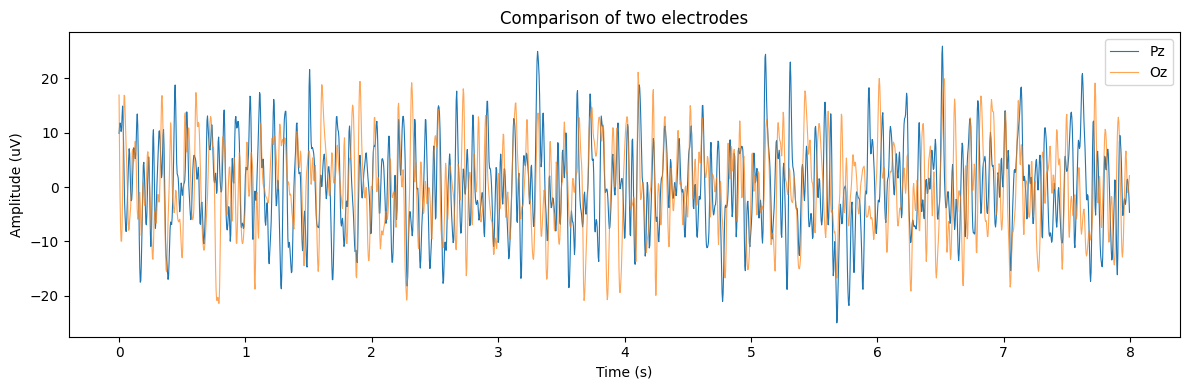

In [18]:
import matplotlib.pyplot as plt

duration = 8
n = int(duration * fs)
t = np.arange(n) / fs

plt.figure(figsize=(12, 4))
plt.plot(t, channel_signal('Pz')[:n], label='Pz', lw=0.8)
plt.plot(t, channel_signal('Oz')[:n], label='Oz', lw=0.8, alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.title('Comparison of two electrodes')
plt.legend()
plt.tight_layout()
plt.show()

---
### ✏️ Exercises
1. Display the signal of the `Cz` channel and compute its maximum amplitude.
2. How many seconds separate the first two targets? (hint: use `pos_target` and `fs`)
3. Write a loop that prints, for each channel, its mean value.

### 🔑 Key takeaways
- Python indexes **starting from 0**.
- A 2D EEG array is read as **`data[channel, time]`**.
- `np.where(trig == 2)` gives the **positions of target stimuli**.
- Convert samples → seconds by **dividing by `fs`** (250 Hz).
